In [3]:
%pip install -U google-generativeai
%pip install google-ai-generativelanguage==0.6.15
%pip install -U langchain-google-genai
%pip install -U langchain-community
%pip install -U langgraph
%pip install -U langgraph langchain-community
%pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated, List
import operator

import google.generativeai as genai
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

from langchain_community.tools.tavily_search import TavilySearchResults

c:\Users\MarcosRibeiro\AppData\Local\Programs\Python\Python314\Lib\site-packages\google\auth\transport\grpc.py:43: FutureWarning: grpcio < 1.83.0 does not support Post-Quantum Cryptography (PQC). Support for non-PQC environments is deprecated. In April 2027, google-auth will raise its minimum requirements to enforce grpcio >= 1.83.0. For more details on Google Cloud's post-quantum security migration, visit: https://cloud.google.com/security/resources/post-quantum-cryptography
  warnings.warn(
c:\Users\MarcosRibeiro\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\MarcosRibeiro\AppData\Local\Temp\ipykernel_2872\653529683.py:5: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please swit

In [ ]:
from collections.abc import Sequence
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMassage], operator.add]


In [ ]:
from langchain_core.agents import AgentFinish
from langchain_core.agents import AgentAction
from ctypes import Union
class AgentState(TypedDict):
  input: str
  chat_history: list[BaseMessage]
  agent_outcome: Union[AgentAction, AgentFinish, None]
  intermediate_steps: Annotated[list[tuple[AgentAction, str]], operator.add]


In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

os.environ['GOOGLE_API_KEY'] = os.getenv('GEMINI_API_KEY') 
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [9]:
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


C:\Users\MarcosRibeiro\AppData\Local\Temp\ipykernel_2872\1287549681.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [10]:
class AgentState(TypedDict): 
    messages: Annotated[list[AnyMessage], operator.add]


In [11]:
class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [12]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

model = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

abot = Agent(model, [tool], system=prompt)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


In [13]:
mermaid_code = abot.graph.get_graph().draw_mermaid()
print(mermaid_code)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	llm(llm)
	action(action)
	__end__([<p>__end__</p>]):::last
	__start__ --> llm;
	action --> llm;
	llm -. &nbsp;False&nbsp; .-> __end__;
	llm -. &nbsp;True&nbsp; .-> action;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



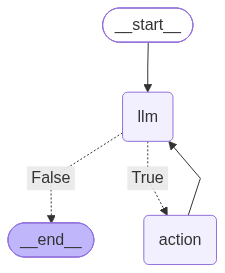

In [14]:
from IPython.display import Image, display

try:
    
    image_data = abot.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))

except Exception as e:
    print(f"Erro ao tentar gerar PNG do Mermaid: {e}")
    print("\nCertifique-se de que a sua versão do LangGraph possui o método `.draw_mermaid_png()`.")
    print("Como alternativa, use `.draw_mermaid()` para obter a string e visualizar externamente.")

In [15]:
%pip install -U langchain-tavily

Note: you may need to restart the kernel to use updated packages.


In [19]:
from langchain_core.messages import BaseMessage
class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], operator.add]

class Agent:
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_gemini)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t_call in tool_calls:
            print(f"Calling tool: {t_call['name']} with args: {t_call['args']}")
            if t_call['name'] not in self.tools:
                print("\n ....bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t_call['name']].invoke(t_call['args'])
            results.append(ToolMessage(tool_call_id=t_call['id'], name=t_call['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [20]:
from langchain_tavily import TavilySearch


prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""
model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearch(max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)

messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]

print("Iniciando interação do agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em S\\u00e3o Paulo hoje", "topic": "general"}'}, '__gemini_function_call_thought_signatures__': {'3cfede96-0707-44e0-a9a1-8b500ee6f390': 'Cu4DAWkUfRPjqHN3MDjtYE6LrGJs4g57j8EfNjv03o4a4NwoRkOGXHQr/aPsdQefjbO7fun770VOr6fo67fciym8M+CoQpcXNqkxPvpWGgMVjbM8dmIUiB5cdot+YQxFDMGvGvIxEywu06A6zupa58bWKap0FZOAcc0D/hxiNTFUxcJowQmsrtikjGXwwZd3MHvGXoPJUj73wYwCU3iLFVkn4XEGcdAvAaWB4pCwrv4tpHHtT3FDr03b+kJJUVNRF0AjAO3cqtTIfTxwNYSk75k9Hh/TKAfK88UFrSt6y3uRqGIpzolPYo5n/wQuAjtxtZLqLH0iVVSGYpSYo2B4VeSFKr9ZnUjap7qoZnBJQHMmFs8cWQSBGADQswTHE9WwyohimB4y5WMOcGBRWt6bYB4OpBtwLozljXkgTK7hR7DCT8cJxrVcxHMQW3+4r0IBkigmpuaWI7cJRSTtA6dfq2EPdtXs4v0fCugYsNTbb2wyv7lPZJ3uqH9Z8v0BUhzTx4nbm28sCBkIYgBXJWqWa7PzGl/C4Rcoa1EI77RDEK3ltTZ7baeD35TvDy0lQsor9m9G5rE4hY5mTt4i/VER0Uhlpd1cewXHx/7BnNMSWaB5HPP3KIUFVz2Jz08Fb4963ralxjNvRiqrZnvGBavPgtQ='}}, response_metadata={'finis

In [21]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""
model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearch(max_results=4)

abot = Agent(model_instance, [tool_instance], system=prompt)

messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")]

print("Iniciando interação do agente:")
final_result_state = None

for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em S\\u00e3o Paulo hoje", "topic": "news"}'}, '__gemini_function_call_thought_signatures__': {'9a3d2233-2586-4e77-9fca-3ed0a08dfa72': 'Cs8CAWkUfRMHtUhFIuvFcjrpB4LeqVmfZLB/QaT3MQ1VygwkJzwbjWUCDMrnyg52SZtf1qcXoOeYX+tOyIYWNSMPGdWMFwFiBrT3yIJWhYSkUG8MukxwwtOP4wUB3h2lipokvpFwIUVU8wksfx5frjQp7ZChHARGWVjGOnGETJm68UTKafYe9nwarSIJrhuc6mxihphpCueumRqoMsi5tBtlHWrztNCk83Nfs9k6VZEtzyrGguAlJYPbRYFAex0/0SnnMqoePtaGZ1sMM4pyJpNuODAqCtmzHM1PEHQuHNMmnuxaw45pGzyFsqD/IH79Di/W2qPEbsgmPVuwicfqAq/KNR2LWNFkg9dz+GIXd73+z1Fd2SLlZRTSxSu980mJUEu2FKrToGQNaVloUT3MN5TsQ5uaSYzAAlGXzuLdZJagUxo2zthIqu1gLw2vaToqHnY='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0fbab-7342-7691-97b8-2e9af2eaab2f-0', tool_calls=[{'name': 'tavily_search', 'args': {'quer

In [22]:
from datetime import date
current_date = date.today().strftime("%d/%m/%Y") # Formato dd/mm/aaaa

prompt = f"""Você é um assistente de pesquisa inteligente e altamente atualizado. \
Sua principal prioridade é encontrar as informações mais RECENTES e em TEMPO REAL sempre que possível. \
A data atual é {current_date}. \
Ao buscar sobre o tempo ou eventos que se referem a "hoje" ou "agora", \
você DEVE **incluir a data atual '{current_date}' na sua consulta para a ferramenta de busca**. \
Por exemplo, se a pergunta é "tempo em cidade x hoje", a consulta para a ferramenta deve ser "tempo em cidade x {current_date}". \
Ignore ou descarte informações que claramente se refiram a datas passadas ou futuras ao responder perguntas sobre "hoje". \
Use o mecanismo de busca para procurar informações, sempre buscando o 'hoje' ou o 'agora' quando o contexto indicar. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
""" 

model_instance = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tool_instance = TavilySearch(max_results=4)
abot = Agent(model_instance, [tool_instance], system=prompt)

user_query = "Como está o tempo em São Paulo hoje?"

messages = [HumanMessage(content=user_query)]

print("Iniciando interação do agente:")
final_result_state = None
for s in abot.graph.stream({"messages": messages}):
    print(s)
    print("---")
    final_result_state = s

print("\nResultado Final:")
if final_result_state and 'llm' in final_result_state and final_result_state['llm']['messages']:
    print(final_result_state['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


Iniciando interação do agente:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em S\\u00e3o Paulo 02/10/2026"}'}, '__gemini_function_call_thought_signatures__': {'5d5c4db8-0fef-4b55-9823-bc7c8413efd3': 'CvkBAWkUfRM7tt/LOUVDbus8Ql1g8oE8T1PBYqrUCen73p3s85u6vA6ip7XPbJlIx9aqcdhOszlk6skCdGM1zUq1VoKHmLFG7bV2cE7lIloAke45s7o9qjaj6Jq0HXwDX4FWK5l8/Nt3U+hu5m86Xuv74inNZjYkySIs6IhEEft9Ijkcx6wSz7PuRDE+ZLNuWSOUp588mboQOGeYP0FwipZJziHxRCHVw5jFEGWpGbBVPEq41epT1Gw/AeKO2/uvp7JxVRE7VeGrKEHFLWMZgEf4b3V+e3VjBfEqfNCfF9i0CmE3cJh9IJYCWygh3iP6wajuTwCnLaLDq3NA'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0fbaf-4c05-7900-8007-d6784bcb675f-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'tempo em São Paulo 02/10/2026'}, 'id': '5d5c4db8-0fef-4b55-9823-bc7c8413efd3', 'type': 'tool_call'}], invalid_tool_calls=[

In [23]:

user_query_tomorrow = "Como está o tempo em São Paulo amanhã?" #atualizamos apenas a pergunta do usuário

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente para amanhã ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final para amanhã ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado para amanhã.")


--- Iniciando interação do agente para amanhã ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "tempo em S\\u00e3o Paulo 03/10/2026"}'}, '__gemini_function_call_thought_signatures__': {'0b78dab8-f30a-445e-b37f-e405b1bb5d6b': 'CqwCAWkUfRPWwz1Ez3a6JO23Z8HsUbEjDR+YcxUQa/HXzAxr0vH3GFHLjxjLsyArnzBePbfzJBHcuGAJZ8qnVXPE2lSyNU1OeC2U0y7UH5rVJv7cigCLVf1XpFPP8MLqp5mKmxBeppj5P2lUgxuTXjhAyQpvMWJ4NHche4E9uL6yzcsOVQDU1cym/8gTA4zTsglSWkpNr5iMhic4qgQoxvc50J3/F41ypiUXvaQbo+pAn+lJr5WxHa4+k/C+NTx8kXYmIlMpQ/lqOMufJqBsIkQdaXxkkCl9ArMYfDihYLbQOlEjPV3Hwuel9qztqHUyZBeCSzX4Qi8Lxia5kwq2JJSkAVsTrTHBVeLLFHD/8cwYzOXACyp4LpBqfyxQ/syeKOOQGuJt7ch+NB3bqEQb'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0fbaf-c6be-76e0-9bf4-b667fc726235-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'tempo em São Paulo 03/10/2026'}, '

In [24]:
from langchain_core.messages import HumanMessage

user_query_tomorrow = "Como foi o tempo em São Paulo ontem?" 

messages_tomorrow = [HumanMessage(content=user_query_tomorrow)]

print("\n--- Iniciando interação do agente ---")
final_result_state_tomorrow = None
for s in abot.graph.stream({"messages": messages_tomorrow}):
    print(s)
    print("---")
    final_result_state_tomorrow = s

print("\n--- Resultado Final  ---")
if final_result_state_tomorrow and 'llm' in final_result_state_tomorrow and final_result_state_tomorrow['llm']['messages']:
    print(final_result_state_tomorrow['llm']['messages'][-1].content)
else:
    print("Nenhum resultado final ou resultado inesperado.")


--- Iniciando interação do agente ---
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"end_date": "2026-10-01", "query": "tempo em S\\u00e3o Paulo"}'}, '__gemini_function_call_thought_signatures__': {'712eb321-4ae2-49af-92b5-b47df0ea8bcb': 'CoQDAWkUfRNUO1txIkwlzWoKGuPAKbLSwXrHz2n/DkBFYp7ZRGmvVBhvMXle6bukNSm0FCjsLf/kmtRIC4wg2mn3crN2PJOtLXM8ZlZ98pnlLbVSCSEM2bRuZRvP+19CbRxIHMzf2PiV30iG0g9gGvHFMpUMr2PWB8g55zvJ7by5qA4oiGQiX3Q11gI6fyZ77/sjo0Yh5+Xno9G80a+y3gFNeVNj2ZlNp0HDalu/Qqm/rtyA0AJco1Ee3MFj8dX2pizSX09GPHKA/tbvBzAJYk6r8tTGvpyoWFtueD5/6WrZCxk3I4nMi/A4pBwwjeV4i75o7ocJrecK2u7aR0EYO1lfSteA9+l+PaJ/rM4WIZ34xqQsoHzI+qeaPOZd0oJBoMMb25tj4EXmDkkXlpR/+30LumoaM+WvQlY7Z8zz9EDIZWauZtB/4yRXJpQKI2V1oeb1O44aPJDmafI6/hPhfZbloZQUap3WUeX5vWhrXo6cg/tsVWVS8K5ibm0cEbpxMmikZomZOw=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0fbb0-

Então, vamos chamar novamente este agente, perguntando: "Qual é o tempo em SP hoje? Dessa vez, vamos olhar em detalhes o que o agente buscou e como ele o fez.

In [25]:
messages = [HumanMessage(content="Como está o tempo em São Paulo hoje?")] 
result = abot.graph.invoke({"messages": messages}) 

Calling tool: tavily_search with args: {'query': 'tempo em São Paulo 02/10/2026'}
Back to the model!


In [26]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Em São Paulo, hoje, 2 de outubro de 2026, a previsão é de sol com aumento de nuvens pela manhã e pancadas de chuva à tarde e à noite. A temperatura mínima será de 16ºC e a máxima de 29ºC. Há também a possibilidade de chuva rápida durante o dia e à noite, com temperaturas variando entre 19°C e 23°C.',
  'extras': {'signature': 'CqwFAWkUfRONz4QTwsLMFZb+r252/1dhyf9uf2EPnFIq71RU0u+ctOP6RGBhLzG13sjCem9znLzPkYNEbNPqgl1bZNpLLv/BbJq1QW7f7r5fcqiWw4yZwdNUCHr0M0ZyzC8ORBsEvOoj0qgKJmL5VWURp4qKjW/T6Ej/w+M1T9M7gN7fLwFHDXBVShyCvK5J3PWCldMHmSlLZYlpDG7FLKgwdWQdw1DElXFAS2dvcp8H+BbI9xv7Gk1a72pYiSIzQI+l3VcBhCdzBMImaTS/1l/U0Bsg2kVtYow/7318CHKn2SK6o9vsCy3WylHVIqNHE1k+0e5xQ7ed9vkhlXUpaUGkU6tAlF+NEhVPV6AvTrCJdzxrcjzQixrHCUvS9ZKOG9x1f1kJmh2HuDG28s7vAF0gArJ/8IoeFAh1zBu8/bkXJQx6OPkTsl3CRE1JRjdT2HCsU2Tvos2IFSyK0hcwUoX4fb+wm6IzkhabsXLVvoNQ/oC0M7tZlS74iE74vSLJNyIlN2qT635EuNlK2uhd3xu3ko90TuKrgsSuauG5+CjWOBWVhKtnuBAAaTSu8rb0KZ3fFtr3/ZaalxfBYUjIxk/ymydiSVBr2ZKZanQ4LcywW3tVJ/ChB6unJDTYO0KZYC

In [27]:
messages = [HumanMessage(content="Como está o tempo em São Paulo e no Rio de Janeiro hoje?")]
result = abot.graph.invoke({"messages": messages})

Calling tool: tavily_search with args: {'query': 'tempo em São Paulo 02/10/2026'}
Calling tool: tavily_search with args: {'query': 'tempo no Rio de Janeiro 02/10/2026'}
Back to the model!


In [28]:
result['messages'][-1].content

[{'type': 'text',
  'text': 'Em São Paulo, hoje, 02/10/2026, a previsão é de sol com aumento de nuvens pela manhã e pancadas de chuva à tarde e à noite. As temperaturas devem variar entre 16°C e 29°C.\n\nNo Rio de Janeiro, hoje, 02/10/2026, o tempo será de sol com muitas nuvens durante o dia e períodos de céu nublado, com muitas nuvens à noite. As temperaturas ficarão entre 20°C e 31°C. Há possibilidade de chuva fraca e irregular.',
  'extras': {'signature': 'CpUJAWkUfRMgYJXv0QnHnqKilB1/CWeQE6+a8DXMa3KW1qn1nnmoxCWfZYyrBNwZMS4IeUpZJxElWgv+g+ZLfdxfR3QlnjHAT93yzt7iVVct0JZt6UeCREVwTx0fl/i5icW58/N4+Jmk47VKSnNp18xLyMuXJiz91Y3Euu6LQEj9tULtcictJFmXkbyLxcb8vrSJL21QtJS8+zB638Dll2xq3IouSwEWHl8sHBULc/KeVtZSNrd0lZilpDD9SZDTD+u9mowGTJimR93JSrpgX/HUfnk4jHdV9uGl6Wx/j2s2XHApsyKa9NTfqywLyUMP5vFYQb4PJf3vOWizeYodAU9kE8fYpoUX6vSe2N7yYo9IBK/E3JMLn4pdbtEndH9CaaSXQDKNBmOBUkND+mSIC4+4y+2NhJpx3dFqYNXz/BuC4w/+SUuk2SEX1BZIzIZkcwFopKjrq6/pCRRcisbQUD8XXP9T2IUvg7aR7LT6//6F1ycoDselS6kvg5zYykuWod4wJC1om6qc94+Pk0yMsDYT

In [29]:
query_passado = "Qual país sediou a Copa do Mundo de futebol em 1998? Quem foi o campeão e qual o placar da final? \
Qual era o Produto Interno Bruto (PIB) desse país no ano da Copa e qual é o PIB atual (últimos dados disponíveis, como 2023 ou 2024)? \
Qual a capital desse país e qual sua moeda atual? Responda a cada pergunta separadamente."
messages = [HumanMessage(content=query_passado)]

print("\nIniciando interação do agente para pergunta sobre o passado:")

current_state = {}
for s in abot.graph.stream({"messages": messages}):
    current_state.update(s)
    print(s)
    print("---")

print("\n--- Resultado Final para o Passado ---")
if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
    final_message_content = current_state['llm']['messages'][-1].content
    print(final_message_content)
else:
    print("Nenhum resultado final ou resultado inesperado. Verifique os logs acima.")



Iniciando interação do agente para pergunta sobre o passado:
{'llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "Qual pa\\u00eds sediou a Copa do Mundo de futebol em 1998?"}'}, '__gemini_function_call_thought_signatures__': {'4ecf5215-32d4-4974-af32-e5e4a1b20b44': 'CoUGAWkUfROy3ScV0yw3+K0+rrbkctHsTqAO5zn0NOb8nItRU3o+mv+4WMdpp50p7lxitLKLdU+BgLn51vmEXE/nJRF/CjrA5HA7lDXNuthrC81Bs2sfNacMxvW9E4k9MtBhmOAUD1R1BLU6BgGTO628WTi8gOKde0SuHSlKtFC9kqFNCEqcILrIv+DK+C1YGUibRxK0IBVY+G6gZd5soW5fL3t/FhYsOdgYRWCSqasPFs0Fp99erhK9g3AbGD+4LManHhHhBP8qgrPdqOwhGumIaGpH+8TBEL6nMTuwAFFRwBxUTeclRxCXFWnXrMQyRO1vRjs5IkJsVLl2i9N2+NEr+h2ixafM7qnPSD5SD9P0CDvDUi+87rD647+rhall5SvcQ6snLPiO7d5y7ihL5Nj2ufAfhOxdfTQggM7eC/u9CoMzBSgVykzIRRk0bO481S98x5DfXnhhVqgA4mJ1kwkMnVOEQ77GJ9pLlt5Ezj1Ef3SNwKPLf+yXOKD1uJgOk6morDAfhhMpBLaXdFR8I0MvkdTCGDY2l05GDVJt3+9EzrwAPaDejRwUl14zLcplzoSenD+IafMcOtZr/sSkxTSmX20OH2uLVugDmO6JmwRoEahYntYE2zO1My00RwL8RK222D6Nvu7zSj

In [30]:
print("\n--- Agente de Pesquisa Interativo ---")
print("Digite sua pergunta ou 'sair' para encerrar.")

while True:
    user_input = input("\nVocê: ") 
    if user_input.lower() == "sair":
        print("Agente: Encerrando a conversa. Até logo!")
        break

    messages = [HumanMessage(content=user_input)]

    print("Agente: Pensando e buscando...")
    final_result_state = None
    try:

        current_state = {}
        for s in abot.graph.stream({"messages": messages}):
            current_state.update(s)

        print("\nAgente:")

        if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
            final_message = current_state['llm']['messages'][-1]
            if hasattr(final_message, 'content'):
                print(final_message.content)
            else:
                print("Não foi possível extrair o conteúdo da resposta final do LLM.")
        else:
            print("Não foi possível obter uma resposta do agente para esta pergunta.")

    except Exception as e:
        print(f"Agente: Ocorreu um erro durante a execução: {e}")
        print("Tente novamente ou digite 'sair'.")

print("\n--- Conversa Encerrada ---")


--- Agente de Pesquisa Interativo ---
Digite sua pergunta ou 'sair' para encerrar.
Agente: Pensando e buscando...
Calling tool: tavily_search with args: {'query': 'melhores práticas para utilizar Langchain e Langraph'}
Back to the model!

Agente:
[{'type': 'text', 'text': 'Para utilizar Langchain e LangGraph de forma eficaz, é importante entender quando usar cada um e seguir as melhores práticas para ambos:\n\n**Quando usar LangChain:**\n\n*   **Fluxos de trabalho lineares e simples:** Ideal para pipelines RAG (Retrieval Augmented Generation), perguntas e respostas de uma única vez, cadeias de prompt e sumarizadores.\n*   **Fluxos de trabalho previsíveis:** Quando o processo é direto, sem ramificações frequentes ou retornos.\n*   **Prototipagem rápida:** Excelente para iniciar rapidamente e integrar com diversas ferramentas.\n*   **Memória de curto prazo:** Suficiente quando a memória é necessária apenas para uma única execução.\n\n**Melhores Práticas para LangChain:**\n\n*   **LCEL (